In [2]:
pip install pytesseract


In [3]:
import numpy as np
import cv2
import imutils
import pytesseract
import pytesseract as ocr
from matplotlib import pyplot as plt

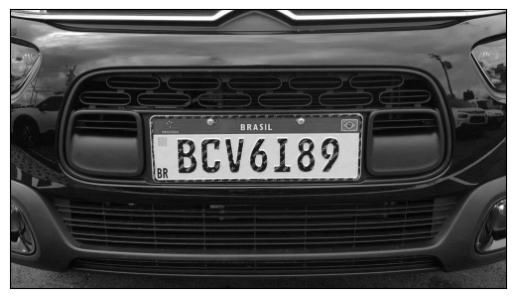

In [118]:
#Carregando imagem teste
original=cv2.imread("placa2.jpg")
original=cv2.cvtColor(original, cv2.COLOR_RGB2BGR)
original=imutils.resize(original, width=500)
gray=cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap=plt.cm.gray), plt.xticks([]), plt.yticks([])
plt.show()

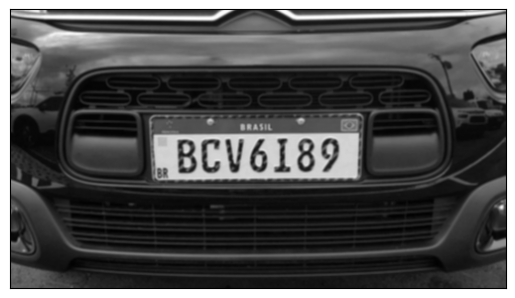

In [119]:
img_filter=cv2.GaussianBlur(gray, (3,3), 1)
plt.imshow(img_filter,cmap=plt.cm.gray), plt.xticks([]), plt.yticks([])
plt.show()

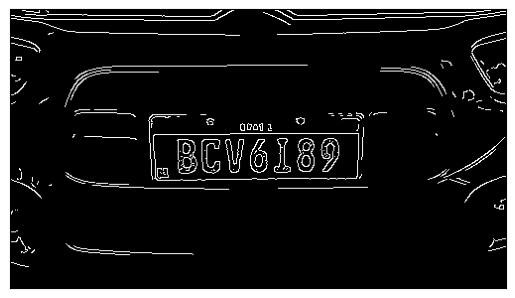

In [120]:
#Detecção de bordas por Canny
canny=cv2.Canny(img_filter, 200, 230)
plt.imshow(canny,cmap=plt.cm.gray), plt.xticks([]), plt.yticks([])
plt.show()

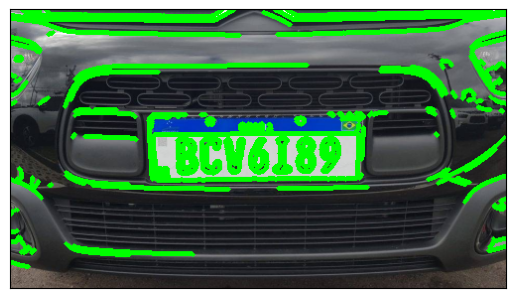

In [121]:
# Detectando e desenhando contornos
contornos, _ = cv2.findContours(canny.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
draw = cv2.drawContours(original.copy(), contornos, -1, (0,255,0), 4)
plt.imshow(draw,cmap=plt.cm.gray), plt.xticks([]), plt.yticks([])
plt.show()

(<matplotlib.image.AxesImage at 0x7d29357b3bc0>, ([], []), ([], []))

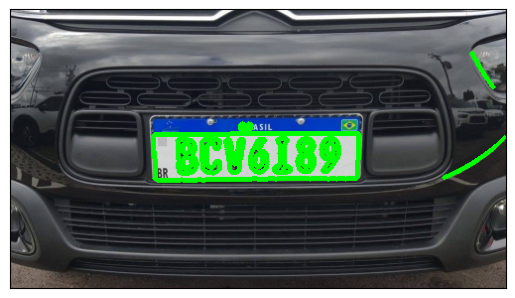

In [122]:
#Reduzindo a quantidade de contornos
contornos=sorted(contornos,key=cv2.contourArea, reverse=True)[:30]
#Reduzindo para contornos de área até 30
draw30 = cv2.drawContours(original.copy(), contornos, -1, (0,255,0), 3)
plt.imshow(draw30,cmap=plt.cm.gray), plt.xticks([]), plt.yticks([])

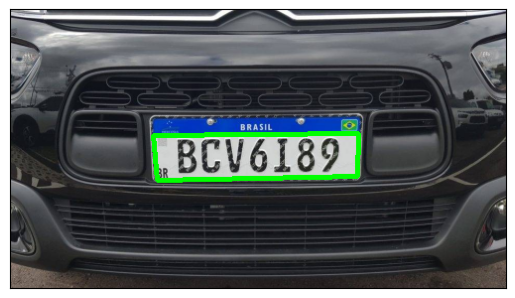

In [123]:
#Recortando a placa
NumPlacaCnt = None
count = 0
idx = 1

for c in contornos:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.01*peri, True)
    if len(approx) == 4:
        NumPlacaCnt = approx

        x,y,w,h = cv2.boundingRect(c)
        new_img = gray[y:y+h,x:x+w]
        cv2.imwrite('Placa' + str(idx) + '.png' , new_img )
        break

detectada = cv2.drawContours(original, [NumPlacaCnt],-1, (0,255,0), 3)

plt.imshow(detectada,cmap=plt.cm.gray), plt.xticks([]), plt.yticks([])
plt.show()

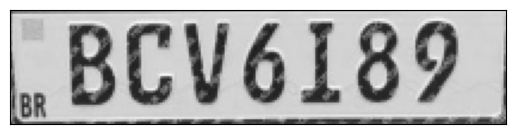

In [124]:
cortada = 'Placa' + str(idx) + '.png'
plt.imshow(cv2.imread(cortada),cmap=plt.cm.gray), plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
cv2.imwrite("placamercosul.jpg", cv2.imread(cortada))

True

In [ ]:
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [125]:
text = pytesseract.image_to_string(cortada)
print("Numero e:",text)

Numero e: BCV6189 |

